Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Load Cleaned Dataset

In [2]:
DATA_PATH = "../data/processed/reviews_clean.csv"

df = pd.read_csv(DATA_PATH)

print(f"Loaded {df.shape[0]} cleaned reviews")


Loaded 851363 cleaned reviews


Rating Distribution

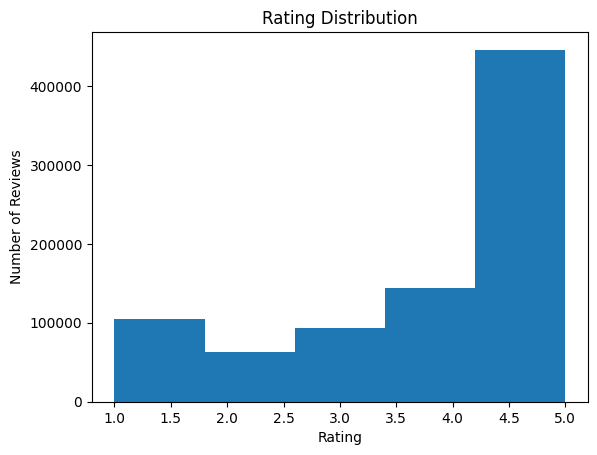

In [3]:
plt.figure()
plt.hist(df["overall"], bins=5)
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.show()


Review Length Distribution

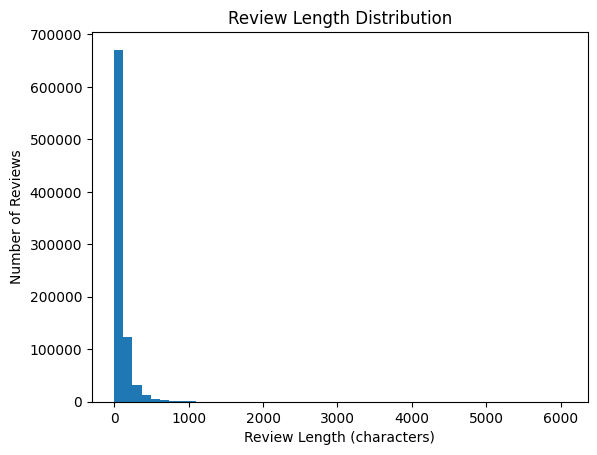

In [4]:
df["review_length"] = df["clean_review_text"].fillna('').apply(len)

plt.figure()
plt.hist(df["review_length"], bins=50)
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.title("Review Length Distribution")
plt.show()


Reviews per User

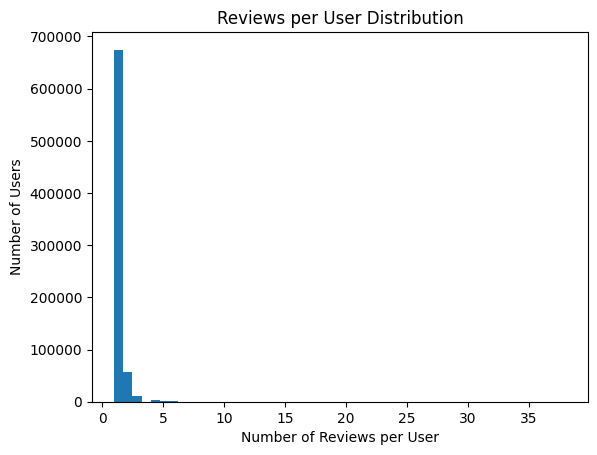

In [5]:
reviews_per_user = df["reviewerID"].value_counts()
plt.figure()
plt.hist(reviews_per_user, bins=50)
plt.xlabel("Number of Reviews per User")
plt.ylabel("Number of Users")
plt.title("Reviews per User Distribution")
plt.show()


Reviews per Product

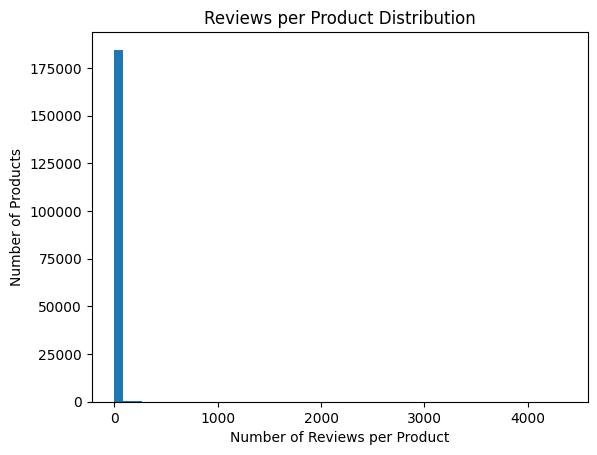

In [6]:
reviews_per_product = df["asin"].value_counts()
plt.figure()
plt.hist(reviews_per_product, bins=50)
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Reviews per Product Distribution")
plt.show()


Helpful Vote Analysis

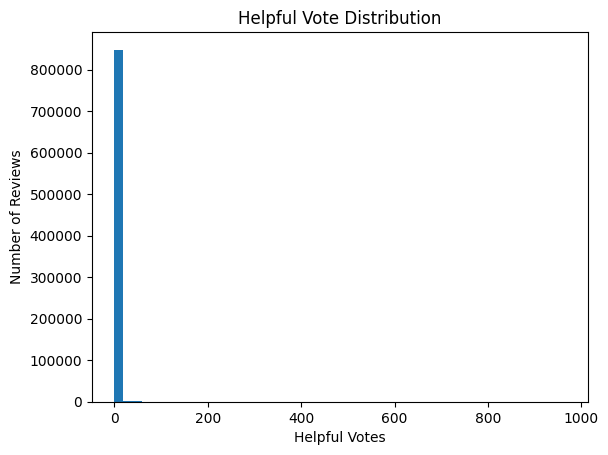

In [7]:
plt.figure()
plt.hist(df["vote"], bins=50)
plt.xlabel("Helpful Votes")
plt.ylabel("Number of Reviews")
plt.title("Helpful Vote Distribution")
plt.show()


Rating Deviation Visualization

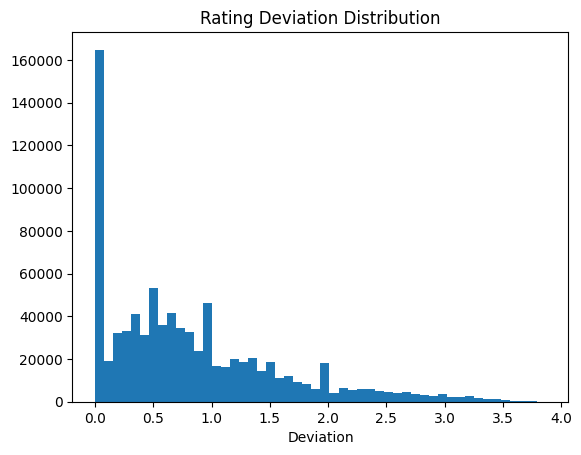

In [8]:
product_mean = df.groupby("asin")["overall"].transform("mean")
df["rating_deviation"] = abs(df["overall"] - product_mean)

plt.figure()
plt.hist(df["rating_deviation"], bins=50)
plt.title("Rating Deviation Distribution")
plt.xlabel("Deviation")
plt.show()


In [9]:
# Quantitative Summary Statistics
print("Key Quantitative Findings:")
print("="*50)

# Rating distribution
rating_counts = df['overall'].value_counts().sort_index()
print(f"\n1. Rating Distribution:")
for rating, count in rating_counts.items():
    pct = (count / len(df)) * 100
    print(f"   {rating}-star: {count:,} ({pct:.1f}%)")

pct_4_5 = ((rating_counts.get(4, 0) + rating_counts.get(5, 0)) / len(df)) * 100
print(f"   4-5 star reviews: {pct_4_5:.1f}%")

# Rating statistics
print(f"\n2. Rating Statistics:")
print(f"   Mean rating: {df['overall'].mean():.2f}")
print(f"   Median rating: {df['overall'].median():.1f}")
print(f"   Skewness: {df['overall'].skew():.2f} (negative = left-skewed toward high ratings)")

# Review length
df['review_length'] = df['reviewText'].fillna('').str.split().str.len()
print(f"\n3. Review Length:")
print(f"   Median length: {df['review_length'].median():.0f} words")
print(f"   Mean length: {df['review_length'].mean():.1f} words")
short_reviews = (df['review_length'] < 20).sum()
print(f"   Reviews < 20 words: {short_reviews:,} ({short_reviews/len(df)*100:.1f}%)")

# Helpful votes
df['helpful_votes'] = df['vote'].fillna(0)
print(f"\n4. Helpful Votes:")
print(f"   Median helpful votes: {df['helpful_votes'].median():.0f}")
no_votes = (df['helpful_votes'] == 0).sum()
print(f"   Reviews with 0 helpful votes: {no_votes:,} ({no_votes/len(df)*100:.1f}%)")

# User activity
user_review_counts = df.groupby('reviewerID').size()
print(f"\n5. User Activity:")
print(f"   Total unique users: {df['reviewerID'].nunique():,}")
single_review_users = (user_review_counts == 1).sum()
print(f"   Single-review users: {single_review_users:,} ({single_review_users/len(user_review_counts)*100:.1f}%)")
print(f"   Median reviews per user: {user_review_counts.median():.0f}")
print(f"   Max reviews by one user: {user_review_counts.max():,}")


Key Quantitative Findings:

1. Rating Distribution:
   1-star: 104,678 (12.3%)
   2-star: 63,076 (7.4%)
   3-star: 93,930 (11.0%)
   4-star: 143,814 (16.9%)
   5-star: 445,865 (52.4%)
   4-5 star reviews: 69.3%

2. Rating Statistics:
   Mean rating: 3.90
   Median rating: 5.0
   Skewness: -0.99 (negative = left-skewed toward high ratings)

3. Review Length:
   Median length: 17 words
   Mean length: 28.3 words
   Reviews < 20 words: 462,532 (54.3%)

4. Helpful Votes:
   Median helpful votes: 0
   Reviews with 0 helpful votes: 773,166 (90.8%)

5. User Activity:
   Total unique users: 748,219
   Single-review users: 674,546 (90.2%)
   Median reviews per user: 1
   Max reviews by one user: 38


## EDA Summary

**Key Quantitative Findings:**

1. **Rating Distribution:** {:.1f}% of reviews are 4-5 stars (mean: {:.2f}, skewness: {:.2f})
   - Strong positive skew indicates ratings are heavily concentrated at high values
   - This creates challenges for distinguishing genuine positive reviews from fake ones

2. **Review Length:** Median of {:.0f} words, with significant variation
   - Many very short reviews may lack substantive content
   - Length alone is insufficient for trust assessment

3. **Helpful Votes:** Median of {:.0f} votes per review
   - Majority of reviews receive no community validation
   - Sparse helpful vote data requires fallback trust signals

4. **User Activity:** {:.1f}% of users write only a single review
   - High proportion of single-review users limits behavioral analysis
   - User consistency metrics have limited applicability

5. **Product Coverage:** Long-tail distribution of reviews per product
   - Some products have extensive review history, others very few
   - Requires Bayesian averaging to handle low-review products

**Implications for Trust Scoring:**

These patterns motivate the need for:
- Multi-signal trust scoring (not relying on any single feature)
- Fallback formulas for sparse data (helpful votes, user history)
- Product-level aggregation with confidence weighting
- Review-level granularity to detect suspicious patterns
